<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/08_planning_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 8 · Planning and search · taste project*

# What's the smartest path through a huge number of choices?

> **In short**
>
> **What's the smartest path through a huge number of choices?**
>
> Keep a list of places to try next. Always take the most promising one, and never check the same place twice. How you rank "most promising" decides which search you get. The same idea solves puzzles and plays games.

## Where you'll end up

By the end you will have built:

1. **Three path-finders** (breadth-first search, Dijkstra and A*) and watched them explore the same map differently.
2. **A sliding-puzzle solver** that searches through 181,440 possible boards.
3. **A Connect Four player** that looks ahead several moves, and that you can play against.

Running every cell takes about a minute.

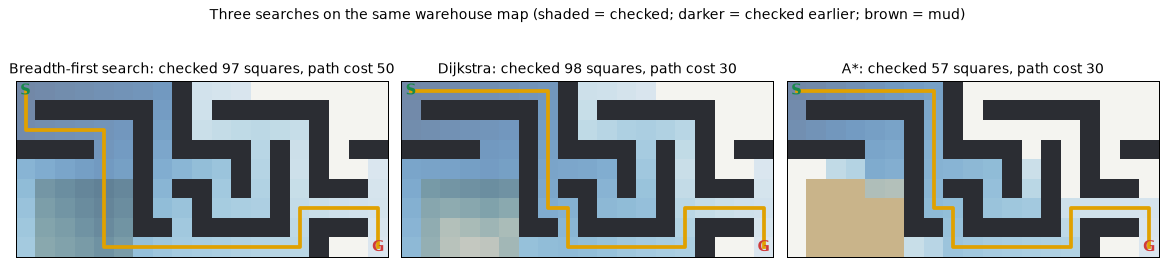

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

In [ ]:
%pip install -q networkx   # graph library, used once near the end (already in Colab)

## 1. The problem: get the robot to G

A warehouse robot starts at **S** and must reach **G**.
`#` is a wall. `~` is a patch of spilled oil: crossing it is allowed but slow (it costs 5 instead of 1).
The robot moves up, down, left or right, one square at a time.

**What is the cheapest route?** This map has 115 open squares. A real warehouse has millions, so trying every route is out.

In [ ]:
WAREHOUSE = [
    "S.......#..........",
    ".######.#.######...",
    "......#.#......#...",
    "####..#.####.#.#.##",
    "......#....#.#.#...",
    ".~~~~~#.##.#.#.###.",
    ".~~~~~#..#...#.....",
    ".~~~~~##.#####.###.",
    ".~~~~~.........#..G",
]
ROWS, COLS = len(WAREHOUSE), len(WAREHOUSE[0])
COST = {".": 1, "S": 1, "G": 1, "~": 5}      # mud costs 5 to cross; "#" is a wall

def find(ch):
    for r, row in enumerate(WAREHOUSE):
        for c, x in enumerate(row):
            if x == ch:
                return (r, c)

START, GOAL = find("S"), find("G")

def neighbours(square):
    r, c = square
    out = []
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and WAREHOUSE[nr][nc] != "#":
            out.append((nr, nc))
    return out

print("\n".join(WAREHOUSE))
print("start:", START, "  goal:", GOAL)
print("open squares next to the start:", neighbours(START))

🐍 **Python notes**
- `WAREHOUSE` is a **list** of strings. `WAREHOUSE[r][c]` is the character in row `r`, column `c`.
- `(r, c)` is a **tuple**: a fixed pair of values. Tuples can be dictionary keys and set members; lists can't.
- `COST = {".": 1, "~": 5}` is a **dict** (a hash map): look up a key, get a value, in constant time.
- `for r, row in enumerate(WAREHOUSE):` loops over the rows and counts them.

## 2. Search 1: check squares in rings

The simplest careful search:

1. Keep a line of squares waiting to be checked. It starts with S.
2. Take the square that has waited **longest**. If it is G, stop.
3. Add its unseen neighbours to the **back** of the line. Remember where you came from.

Because the line is first-in, first-out, squares come out in order of how many steps they are from S: every square 1 step away, then 2 steps, and so on.

In [ ]:
from collections import deque

def bfs(start, goal):
    frontier = deque([start])          # squares waiting to be checked, oldest first
    came_from = {start: None}          # how we reached each square (also marks it as seen)
    checked = []                       # the order squares were checked in
    while frontier:
        square = frontier.popleft()
        checked.append(square)
        if square == goal:
            break
        for nxt in neighbours(square):
            if nxt not in came_from:
                came_from[nxt] = square
                frontier.append(nxt)
    return came_from, checked

def path_to(came_from, goal):
    path = []
    square = goal
    while square is not None:
        path.append(square)
        square = came_from[square]
    return path[::-1]                   # reversed: start to goal

def path_cost(path):
    return sum(COST[WAREHOUSE[r][c]] for r, c in path[1:])

came_from, checked = bfs(START, GOAL)
path = path_to(came_from, GOAL)
print("squares checked:", len(checked))
print("steps on the path:", len(path) - 1, "   cost of the path (mud counts 5):", path_cost(path))

🐍 **Python notes**
- `deque` (from `collections`) is a list that is fast to add to and remove from at both ends. `popleft()` takes from the front.
- `if nxt not in came_from` checks a **dict** in constant time, however big it gets.
- `path[::-1]` is the list reversed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def draw(ax, checked=(), path=(), title=""):
    base = np.zeros((ROWS, COLS))
    for r in range(ROWS):
        for c in range(COLS):
            base[r, c] = {"#": 3, "~": 1}.get(WAREHOUSE[r][c], 0)
    ax.imshow(base, cmap=ListedColormap(["#f4f4f0", "#c9b48a", "#c9b48a", "#2b2d33"]), vmin=0, vmax=3)
    if checked:
        order = np.full((ROWS, COLS), np.nan)
        for k, (r, c) in enumerate(checked):
            order[r, c] = k
        ax.imshow(order, cmap="Blues_r", alpha=0.55, vmin=0, vmax=len(checked) * 1.3)
    if path:
        pr, pc = zip(*path)
        ax.plot(pc, pr, color="#e0a100", lw=3)
    ax.text(START[1], START[0], "S", ha="center", va="center", color="#188a4a", weight="bold", fontsize=12)
    ax.text(GOAL[1], GOAL[0], "G", ha="center", va="center", color="#d03a3a", weight="bold", fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(figsize=(8, 4))
draw(ax, checked, path, f"Search 1: checked {len(checked)} squares (darker = earlier)")
plt.show()

**What you see:** the blue shading spreads out from S in rings, the same in every direction. The yellow path is the one with the fewest steps.
But look where it goes: **straight through the oil**, because this search counts steps, not cost.

**What it's called:** this is **breadth-first search** (BFS). The first-in, first-out line is a **queue**.
Each square and each connection is handled at most once, so the work grows in proportion to the size of the map: $O(V + E)$ for $V$ squares and $E$ connections.

## 3. Search 2: when steps cost different amounts

To respect the oil, take the square with the **cheapest cost so far**, not the one that waited longest.
You need a container that always hands back its smallest item quickly.

### 🤔 Predict first

With cost in charge, **will the new search check more squares or fewer than Search 1?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Usually **more** (or about the same). It explores every route cheaper than the best one, and the oil makes some routes expensive, so it fans out around the oil before committing. Run the next cell.

</details>

In [ ]:
import heapq

def dijkstra(start, goal):
    frontier = [(0, start)]            # (cost so far, square); heapq keeps the smallest first
    cost_so_far = {start: 0}
    came_from = {start: None}
    checked = []
    done = set()
    while frontier:
        cost, square = heapq.heappop(frontier)
        if square in done:
            continue                   # an older, more expensive entry for a square already finished
        done.add(square)
        checked.append(square)
        if square == goal:
            break
        for nxt in neighbours(square):
            new_cost = cost + COST[WAREHOUSE[nxt[0]][nxt[1]]]
            if nxt not in cost_so_far or new_cost < cost_so_far[nxt]:
                cost_so_far[nxt] = new_cost
                came_from[nxt] = square
                heapq.heappush(frontier, (new_cost, nxt))
    return came_from, checked

came_from_d, checked_d = dijkstra(START, GOAL)
path_d = path_to(came_from_d, GOAL)
print("squares checked:", len(checked_d))
print("steps:", len(path_d) - 1, "   cost:", path_cost(path_d))

fig, ax = plt.subplots(figsize=(8, 4))
draw(ax, checked_d, path_d, f"Search 2: checked {len(checked_d)} squares, path cost {path_cost(path_d)}")
plt.show()

🐍 **Python notes**
- `heapq.heappush(h, item)` and `heapq.heappop(h)` keep a plain list arranged so the **smallest** item comes out first. Both take $O(\log n)$ time.
- Tuples compare item by item: `(3, (0, 5)) < (4, (0, 1))` because 3 < 4. So `(cost, square)` sorts by cost.

**What you see:** the new path has the same number of steps as Search 1's, but avoids the oil: cost 30 instead of 50.
Search 1 picked one of several shortest-in-steps routes, and it happened to cross the oil. It never looked at cost.

**What it's called:** this is **Dijkstra's algorithm**. The container is a **priority queue**, built here on a **heap**.
Dijkstra always finds the cheapest path when every step costs zero or more.

## 4. Search 3: aim at the goal

Dijkstra spreads out in every direction, even away from G.
You know where G is. The distance to G, ignoring walls and oil, is easy to compute: rows apart + columns apart.

**Rank squares by cost so far + that estimate of the cost still to go.**

In [ ]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(start, goal, h=manhattan):
    frontier = [(h(start, goal), 0, start)]    # (estimated total, cost so far, square)
    cost_so_far = {start: 0}
    came_from = {start: None}
    checked = []
    done = set()
    while frontier:
        _, cost, square = heapq.heappop(frontier)
        if square in done:
            continue
        done.add(square)
        checked.append(square)
        if square == goal:
            break
        for nxt in neighbours(square):
            new_cost = cost + COST[WAREHOUSE[nxt[0]][nxt[1]]]
            if nxt not in cost_so_far or new_cost < cost_so_far[nxt]:
                cost_so_far[nxt] = new_cost
                came_from[nxt] = square
                heapq.heappush(frontier, (new_cost + h(nxt, goal), new_cost, nxt))
    return came_from, checked

came_from_a, checked_a = astar(START, GOAL)
path_a = path_to(came_from_a, GOAL)
print("squares checked:", len(checked_a), "   cost:", path_cost(path_a))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
draw(axes[0], checked, path, f"Search 1: {len(checked)} checked, cost {path_cost(path)}")
draw(axes[1], checked_d, path_d, f"Search 2: {len(checked_d)} checked, cost {path_cost(path_d)}")
draw(axes[2], checked_a, path_a, f"Search 3: {len(checked_a)} checked, cost {path_cost(path_a)}")
plt.show()

**What you see:** Search 3 finds a path with the same cost as Search 2, but checks fewer squares. Its shading leans toward G.

**What it's called:** this is **A\*** ("A star"). The estimate is a **heuristic**; this one is the **Manhattan distance**. A\* checks next the square with the smallest

$$f(n) = \cg{g(n)} + \cy{h(n)}$$

where $g(n)$ is the cost so far and $h(n)$ the estimate of the cost to go.

**The one rule:** the estimate must **never overestimate** the true remaining cost. A heuristic like that is **admissible**, and then A\* is guaranteed to find the cheapest path.
Manhattan distance never overestimates here: every step costs at least 1, and walls only make routes longer.

### Watch all three explore

In [ ]:
from matplotlib import animation
from IPython.display import HTML

runs = [("Search 1 (BFS)", checked, path), ("Search 2 (Dijkstra)", checked_d, path_d), ("Search 3 (A*)", checked_a, path_a)]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
FRAMES = 30
longest = max(len(c) for _, c, _ in runs)

def frame(k):
    n = int(longest * (k + 1) / FRAMES)
    for ax, (name, chk, pth) in zip(axes, runs):
        ax.clear()
        done = n >= len(chk)
        draw(ax, chk[:n], pth if done else (), f"{name}: {min(n, len(chk))} checked")

anim = animation.FuncAnimation(fig, frame, frames=FRAMES, interval=200)
plt.close(fig)
HTML(anim.to_jshtml())

## 5. The same search, on a puzzle

Search doesn't need a map. It needs **states** and **moves between them**.

The 8-puzzle: eight numbered tiles and one gap in a 3 × 3 frame. A move slides a tile into the gap. The goal is `1 2 3 / 4 5 6 / 7 8 _`.
Each arrangement of tiles is a state. Each slide is a step of cost 1.

### 🤔 Predict first

**How many different arrangements can you reach from the solved puzzle by sliding tiles?** (There are 9! = 362,880 ways to place 9 things.)

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**181,440**, exactly half. A slide can never swap only two tiles, so half of all arrangements can't be reached. Run the BFS below; it visits every reachable one.

</details>

In [ ]:
GOAL_BOARD = (1, 2, 3, 4, 5, 6, 7, 8, 0)          # 0 is the gap

def slides(board):
    """All boards one slide away."""
    gap = board.index(0)
    r, c = divmod(gap, 3)
    out = []
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < 3 and 0 <= nc < 3:
            j = nr * 3 + nc
            b = list(board)
            b[gap], b[j] = b[j], b[gap]
            out.append(tuple(b))
    return out

# BFS over every reachable board, recording each board's distance from the goal
dist = {GOAL_BOARD: 0}
queue = deque([GOAL_BOARD])
while queue:
    b = queue.popleft()
    for nb_ in slides(b):
        if nb_ not in dist:
            dist[nb_] = dist[b] + 1
            queue.append(nb_)
print("reachable boards:", len(dist))
print("hardest boards need", max(dist.values()), "slides")

🐍 **Python notes**
- `divmod(gap, 3)` gives the row and column in one go: `divmod(7, 3) == (2, 1)`.
- `b[gap], b[j] = b[j], b[gap]` swaps two items without a temporary variable.
- A board is a **tuple** so it can be a dict key (a list can't).

Now solve one scrambled board two ways, and count the boards each search checks.

In [ ]:
def solve(start, h=None):
    """A* on boards; with h=None it ranks by slides so far only (the same order as BFS)."""
    h = h or (lambda b: 0)
    frontier = [(h(start), 0, start)]
    came, cost = {start: None}, {start: 0}
    checked = 0
    while frontier:
        _, g, b = heapq.heappop(frontier)
        checked += 1
        if b == GOAL_BOARD:
            break
        for nb_ in slides(b):
            if nb_ not in cost or g + 1 < cost[nb_]:
                cost[nb_] = g + 1
                came[nb_] = b
                heapq.heappush(frontier, (g + 1 + h(nb_), g + 1, nb_))
    path, b = [], GOAL_BOARD
    while b is not None:
        path.append(b); b = came[b]
    return path[::-1], checked

def tile_distance(b):
    """Sum over tiles of how far each tile is from its home square (rows + columns)."""
    total = 0
    for i, t in enumerate(b):
        if t:
            home = t - 1
            total += abs(i // 3 - home // 3) + abs(i % 3 - home % 3)
    return total

scrambled = (8, 6, 7, 2, 5, 4, 3, 0, 1)          # one of the hardest boards
p1, n1 = solve(scrambled)
p2, n2 = solve(scrambled, tile_distance)
print(f"no estimate:        {len(p1) - 1} slides, checked {n1:,} boards")
print(f"with tile distance: {len(p2) - 1} slides, checked {n2:,} boards")

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(13, 1.9))
for ax, k in zip(axes, np.linspace(0, len(p2) - 1, 8).astype(int)):
    b = np.array(p2[k]).reshape(3, 3)
    ax.imshow(b == 0, cmap="Greys", vmin=0, vmax=3)
    for (r, c), t in np.ndenumerate(b):
        if t:
            ax.text(c, r, str(t), ha="center", va="center", fontsize=13)
    ax.set_title(f"slide {k}", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.show()

**What you see:** both find the same number of slides (the minimum), but the estimate cuts the boards checked by a large factor.

**What it's called:** the set of all boards is the **state space**. Searching it without an estimate is **uninformed search**; with one, **informed search**.
"Sum of each tile's distance from home" never overestimates (each slide moves one tile one square), so it is admissible.

## 6. Search against an opponent: Connect Four

Two players drop discs into a 7-column, 6-row frame. The first to line up four wins.
Now each step down the search alternates: **your** move, then **theirs**.

The idea: assume the opponent also plays well. Look ahead a few moves.
On your turns take the move with the highest score; on theirs, expect the move with the lowest.
Score positions at the end of the look-ahead with a quick estimate: count lines of 4 that are still open, weighted by how many discs each side has in them.

In [ ]:
import random
ROWS4, COLS4 = 6, 7

def new_board():
    return [[0] * COLS4 for _ in range(ROWS4)]      # 0 empty, 1 = you, 2 = computer

def legal(board):
    return [c for c in range(COLS4) if board[0][c] == 0]

def drop(board, col, player):
    b = [row[:] for row in board]                     # copy, so the original is unchanged
    for r in range(ROWS4 - 1, -1, -1):
        if b[r][col] == 0:
            b[r][col] = player
            return b

# Every line of 4 squares (across, down, both diagonals), worked out once: 69 lines.
LINES = []
for r in range(ROWS4):
    for c in range(COLS4):
        for dr, dc in [(0, 1), (1, 0), (1, 1), (1, -1)]:
            cells = [(r + k * dr, c + k * dc) for k in range(4)]
            if all(0 <= rr < ROWS4 and 0 <= cc < COLS4 for rr, cc in cells):
                LINES.append(cells)

def windows(board):
    """The contents of every line of 4."""
    for cells in LINES:
        yield [board[rr][cc] for rr, cc in cells]

def winner(board):
    for w in windows(board):
        if w[0] and w.count(w[0]) == 4:
            return w[0]
    return 0

def estimate(board, me):
    """Positive = good for `me`. Open lines with 3 or 2 of my discs score; the opponent's count against."""
    other = 3 - me
    score = 0
    for w in windows(board):
        if other not in w:
            score += {4: 1000, 3: 5, 2: 2}.get(w.count(me), 0)
        if me not in w:
            score -= {4: 1000, 3: 5, 2: 2}.get(w.count(other), 0)
    return score

🐍 **Python notes**
- `[row[:] for row in board]` copies each row. Without the copy, every "what if" would change the real board.
- `yield` makes `windows` a **generator**: it hands back one line at a time instead of building a big list.
- `3 - me` flips between players 1 and 2.

In [ ]:
nodes = 0

def minimax(board, depth, my_turn, me, alpha=-10**9, beta=10**9, prune=True):
    """Best score reachable from here, looking `depth` moves ahead."""
    global nodes
    nodes += 1
    w = winner(board)
    if w or depth == 0 or not legal(board):
        if w:
            return (10**6 + depth) if w == me else -(10**6 + depth)   # sooner wins score higher
        return estimate(board, me)
    player = me if my_turn else 3 - me
    best = -10**9 if my_turn else 10**9
    for col in sorted(legal(board), key=lambda c: abs(c - 3)):        # centre columns first
        score = minimax(drop(board, col, player), depth - 1, not my_turn, me, alpha, beta, prune)
        if my_turn:
            best = max(best, score); alpha = max(alpha, score)
        else:
            best = min(best, score); beta = min(beta, score)
        if prune and alpha >= beta:
            break                     # the other player would never allow this line: skip the rest
    return best

def best_move(board, me, depth=4, prune=True):
    scores = {c: minimax(drop(board, c, me), depth - 1, False, me, prune=prune) for c in legal(board)}
    return max(scores, key=scores.get)

### 🤔 Predict first

Skipping lines that the opponent would never allow should save work. **Looking 5 moves ahead from an empty board, how many positions do you think pruning saves?** About 10%? Half? Most of them?

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Most of them.** Run the next cell. Both versions pick the same move; one checks far fewer positions.

</details>

In [ ]:
for prune in (False, True):
    nodes = 0
    move = best_move(new_board(), me=2, depth=5, prune=prune)
    print(f"pruning {'on ' if prune else 'off'}: chose column {move}, checked {nodes:,} positions")

**What it's called:** looking ahead while assuming the opponent plays their best is **minimax** (maximise your score, assume they minimise it). This is **adversarial search**.
Skipping branches that can't change the decision is **alpha-beta pruning**: `alpha` is the best score you are already sure of, `beta` the best the opponent is sure of. When `alpha >= beta`, the rest of that branch is irrelevant.

Now let the computer play 20 games against a player who picks random columns.

In [ ]:
def play_game(first_random=True, depth=4, seed=0):
    random.seed(seed)
    board, player = new_board(), 1
    while legal(board) and not winner(board):
        if player == 1:
            col = random.choice(legal(board))
        else:
            col = best_move(board, 2, depth)
        board = drop(board, col, player)
        player = 3 - player
    return winner(board)

results = [play_game(seed=s) for s in range(20)]
print("computer wins:", results.count(2), "  random player wins:", results.count(1), "  draws:", results.count(0))

### Play it yourself

Set `PLAY = True` and run the cell. Type a column number (0–6) when asked. You are **X**, the computer is **O**.

In [ ]:
PLAY = False      # change to True to play

def show_board(board):
    for row in board:
        print(" ".join(".XO"[v] for v in row))
    print(" ".join(str(c) for c in range(COLS4)))

if PLAY:
    board, player = new_board(), 1
    while legal(board) and not winner(board):
        show_board(board)
        if player == 1:
            col = int(input("your column (0-6): "))
            if col not in legal(board):
                print("that column is full or doesn't exist"); continue
        else:
            col = best_move(board, 2, depth=5)
            print("computer plays", col)
        board = drop(board, col, player)
        player = 3 - player
    show_board(board)
    print({1: "You win.", 2: "The computer wins.", 0: "Draw."}[winner(board)])

## 7. The library version

Real projects use a graph library. **networkx** turns the warehouse into a graph (squares are nodes, moves are edges with costs) and runs A\* for you.

In [ ]:
import networkx as nx

G = nx.DiGraph()
for r in range(ROWS):
    for c in range(COLS):
        if WAREHOUSE[r][c] != "#":
            for nxt in neighbours((r, c)):
                G.add_edge((r, c), nxt, weight=COST[WAREHOUSE[nxt[0]][nxt[1]]])

lib_path = nx.astar_path(G, START, GOAL, heuristic=manhattan, weight="weight")
print("networkx path cost:", path_cost(lib_path), "   your A* path cost:", path_cost(path_a))

**Same cost.** The library is faster and well tested; now you know what it does inside.

## Practice

Try each one before opening its solution.

### Exercise 1

Make the estimate bigger: try `h = k × Manhattan distance` in `astar` for k = 2, 5 and 10. **Does it still find the cheapest path? Does it check fewer squares?** Explain what you see.

In [ ]:
# your code here

In [ ]:
#@title Solution to exercise 1 (double-click to show)
for k in (2, 5, 10):
    came_k, checked_k = astar(START, GOAL, h=lambda a, b, k=k: k * manhattan(a, b))
    p_k = path_to(came_k, GOAL)
    print(f"k = {k:2d}: checked {len(checked_k)} squares, path cost {path_cost(p_k)} (cheapest is {path_cost(path_a)})")
# Bigger estimates check fewer squares. At k = 10 the path costs 34, not 30:
# the estimate now overestimates, so A* can skip the cheapest route. You trade the guarantee for speed.

### Exercise 2

Write `steps_from(start)` that returns a dict giving the fewest steps from `start` to **every** reachable square of the warehouse (ignore the oil's cost). Then print the square that is furthest from S.

In [ ]:
def steps_from(start):
    ...

In [ ]:
#@title Solution to exercise 2 (double-click to show)
def steps_from(start):
    dist = {start: 0}
    q = deque([start])
    while q:
        s = q.popleft()
        for n in neighbours(s):
            if n not in dist:
                dist[n] = dist[s] + 1
                q.append(n)
    return dist

d = steps_from(START)
far = max(d, key=d.get)
print("furthest square:", far, "at", d[far], "steps")

### Exercise 3

By hand: an empty 4 × 4 grid. You need the fewest moves from the top-left to the bottom-right corner, moving up/down/left/right. **How many moves? How many different shortest routes are there?**

<details><summary><b>Show the answer to exercise 3</b></summary>

6 moves (3 down, 3 right). A shortest route is any order of those 6 moves, so choose which 3 are "down": $\binom{6}{3} = 20$ routes.

</details>

## Recognition cues

- When you see **shortest path where every move costs the same** in a problem, think **breadth-first search with a queue**.
- When you see **cheapest path with different costs** in a problem, think **Dijkstra with a priority queue (heap)**.
- When you see **cheapest path, and you can estimate the distance left without overestimating** in a problem, think **A***.
- When you see **two players taking turns** in a problem, think **minimax, with alpha-beta pruning**.
- When you see **"never process the same state twice"** in a problem, think **a set or dict of seen states**.

## Try changing this

1. **Move the oil.** Edit `WAREHOUSE` so the oil blocks the only short corridor. How do the three searches' counts change?
2. **Change the look-ahead.** Play the computer at `depth=2` and at `depth=6`. Can you beat the shallow one? How long does the deep one take per move?
3. **Diagonal moves.** Allow diagonal steps in `neighbours`. Is Manhattan distance still admissible? (Hint: what is the true cost of one diagonal step?)

## Open research questions

People are working on these right now:

- How do we plan for thousands of robots at once?
- How do we combine learned models with classic search?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Planning and search** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Red Blob Games, *Introduction to A\** (very visual): https://www.redblobgames.com/pathfinding/a-star/introduction.html
- The site's DSA track: queues, heaps and graphs, each with a step-through animation.
- At Monash: FIT5222 Planning and automated reasoning, FIT5047 Fundamentals of AI.